Анализ набора данных Iris и сравнение регрессионных моделей.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# 配置Matplotlib支持俄语显示
plt.rcParams['font.family'] = 'DejaVu Sans'  
plt.rcParams['axes.unicode_minus'] = False   
russian_labels = {
    'sepal length (cm)': 'Длина чашелистика (см)',
    'sepal width (cm)': 'Ширина чашелистика (см)',
    'petal length (cm)': 'Длина лепестка (см)',
    'petal width (cm)': 'Ширина лепестка (см)',
    'species': 'Вид',
    'setosa': 'Ирис щетинистый',
    'versicolor': 'Ирис разноцветный',
    'virginica': 'Ирис виргинский'
}

1. Загрузка и предварительный осмотр набора данных Iris
Загружаем классический набор данных Iris и преобразуем его в удобную таблицу pandas с русскими названиями столбцов.

In [2]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 替换特征名和目标名为俄语
ru_feature_names = [russian_labels[name] for name in feature_names]
ru_target_names = [russian_labels[name] for name in target_names]

df_iris = pd.DataFrame(X_iris, columns=ru_feature_names)
df_iris[russian_labels['species']] = [ru_target_names[i] for i in y_iris]

print("Первые 5 строк набора данных：")
print(df_iris.head())

Первые 5 строк набора данных：
   Длина чашелистика (см)  Ширина чашелистика (см)  Длина лепестка (см)  \
0                     5.1                      3.5                  1.4   
1                     4.9                      3.0                  1.4   
2                     4.7                      3.2                  1.3   
3                     4.6                      3.1                  1.5   
4                     5.0                      3.6                  1.4   

   Ширина лепестка (см)              Вид  
0                   0.2  Ирис щетинистый  
1                   0.2  Ирис щетинистый  
2                   0.2  Ирис щетинистый  
3                   0.2  Ирис щетинистый  
4                   0.2  Ирис щетинистый  


2. Визуализация признаков с помощью pairplot
Строим диаграмму попарного распределения признаков, чтобы визуально оценить разделимость классов ирисов.


pairplot:


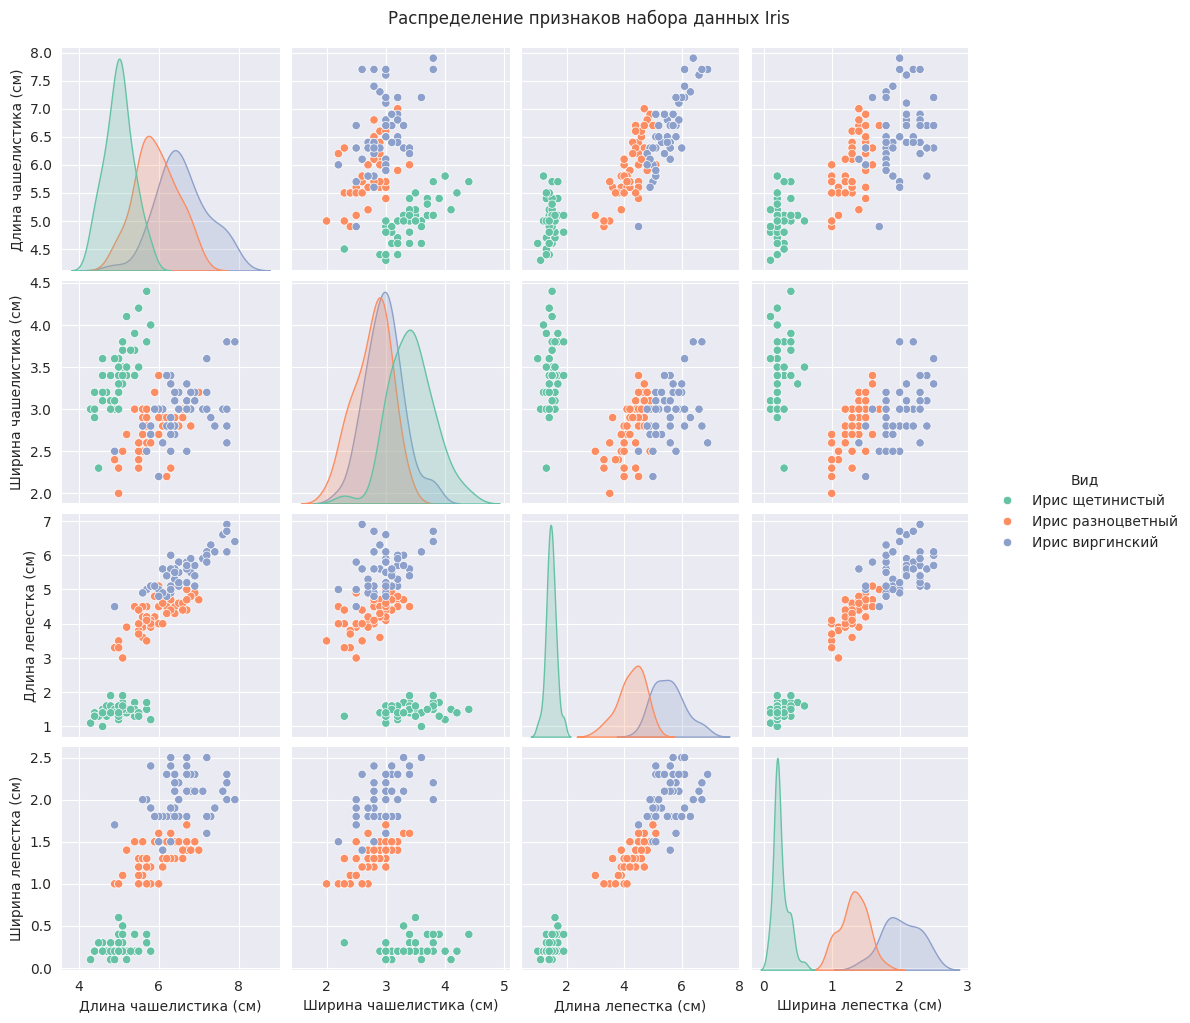

In [3]:
print("\npairplot:")
sns.pairplot(df_iris, hue=russian_labels['species'], palette="Set2")
plt.suptitle("Распределение признаков набора данных Iris", y=1.02)  # 俄语标题
plt.show()

3. Бинарная классификация с помощью Logistic Regression
Используем логистическую регрессию для классификации двух видов ирисов:
Ирис щетинистый (setosa)
Ирис разноцветный (versicolor)

In [4]:
mask = y_iris != 2
X_bin = X_iris[mask]
y_bin = y_iris[mask]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 训练 Logistic 回归
log_reg = LogisticRegression(random_state=42, max_iter=200)
log_reg.fit(X_train_scaled, y_train)

# 预测并评估
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test = log_reg.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("\nРезультаты логистической регрессии:")
print(f"Точность на обучающей выборке: {train_acc:.4f}")
print(f"Точность на тестовой выборке:: {test_acc:.4f}")


Результаты логистической регрессии:
Точность на обучающей выборке: 1.0000
Точность на тестовой выборке:: 1.0000


4. Демонстрация переобучения в линейной регрессии
Создаем искусственные нелинейные данные и сравниваем качество модели при разных степенях полинома:
Недообучение (низкая степень)
Нормальное обучение
Сильное переобучение (высокая степень)


Сравнение полиномиальных регрессий:

Полином 1 степени:
MSE на обучении: 33.9726
MSE на тесте: 36.6982

Полином 3 степени:
MSE на обучении: 3.4733
MSE на тесте: 2.2324

Полином 15 степени:
MSE на обучении: 2.8850
MSE на тесте: 3.5364


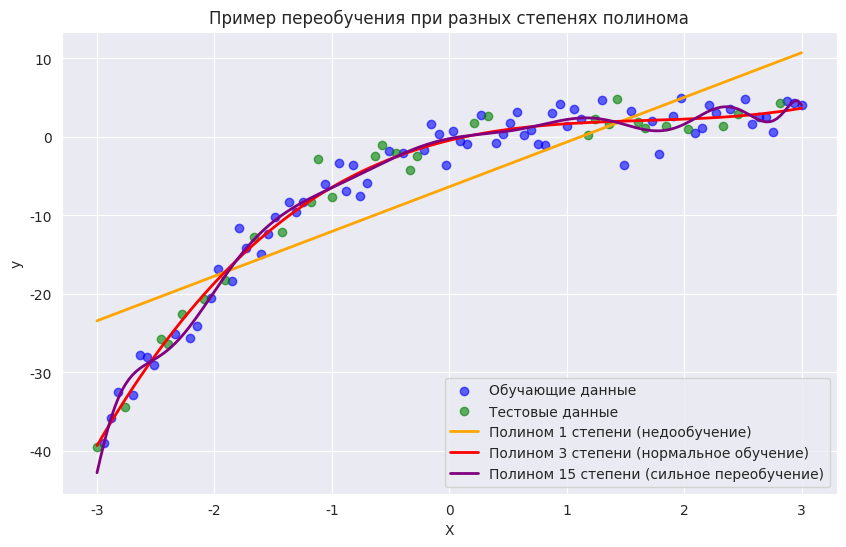

In [5]:
# 生成带噪声的非线性数据
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * X**3 - 2 * X**2 + 3 * X + np.random.normal(0, 2, size=X.shape)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 构造高次多项式特征
def polynomial_features(X, degree):
    return np.hstack([X**i for i in range(1, degree+1)])

# 三个不同阶数，对比过拟合程度
degrees = [1, 3, 15]
colors = ['orange', 'red', 'purple']
labels = [
    'Полином 1 степени (недообучение)',
    'Полином 3 степени (нормальное обучение)',
    'Полином 15 степени (сильное переобучение)'
]

X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Обучающие данные')
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Тестовые данные')

print("\nСравнение полиномиальных регрессий:")
for i, d in enumerate(degrees):
    X_train_poly = polynomial_features(X_train, d)
    X_test_poly = polynomial_features(X_test, d)
    
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_poly, y_train)
    
    y_pred_train = lin_reg.predict(X_train_poly)
    y_pred_test = lin_reg.predict(X_test_poly)
    
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    
    print(f"\nПолином {d} степени:")
    print(f"MSE на обучении: {train_mse:.4f}")
    print(f"MSE на тесте: {test_mse:.4f}")
    
    # 绘制拟合曲线
    X_plot_poly = polynomial_features(X_plot, d)
    y_plot_pred = lin_reg.predict(X_plot_poly)
    plt.plot(X_plot, y_plot_pred, color=colors[i], linewidth=2, label=labels[i])

plt.xlabel('X')
plt.ylabel('y')
plt.title('Пример переобучения при разных степенях полинома')
plt.legend()
plt.show()

Анализ результатов:
1. Результаты визуализации данных: Визуализация распределения четырех основных характеристик ирисов (длина чашелистика, ширина чашелистика, длина лепестка и ширина лепестка) с помощью парного графика позволяет четко наблюдать характерные различия между тремя видами ирисов (Ирис щетинистый, Ирис разноцветный, Ирис виргинский). Среди них Ирис щетинистый обладает наибольшей различимостью по сравнению с двумя другими, а характеристики лепестков (длина и ширина) вносят наиболее значительный вклад в классификацию видов.
2. Результаты бинарной классификации с помощью логистической регрессии: Для задачи бинарной классификации 'Ириса щетинистый' и 'Ириса разноцветный' после стандартизации признаков и разделения набора данных точность модели как на обучающем, так и на тестовом наборах близка к 1,0, что указывает на значительные различия в характеристиках этих двух видов ирисов, и модель логистической регрессии идеально отражает эти различия без явного переобучения или недообучения.
3. Сравнение результатов переобучения линейной регрессии: При сравнении полиномиальных регрессий 1-го, 3-го и 15-го порядков четко представлены явления переобучения и недообучения: полином 1-го порядка (недообучение) не может адекватно аппроксимировать нелинейные данные, что приводит к высокой среднеквадратичной ошибке (MSE) на тестовом наборе; полином 3-го порядка (нормальное обучение) показывает наилучшую аппроксимацию, со сбалансированными значениями MSE как на обучающем, так и на тестовом наборах; полином 15-го порядка (сильное переобучение) переобучает шум на обучающем наборе, что приводит к крайне низкой MSE на обучающем наборе, но значительному увеличению MSE на тестовом наборе, что указывает на крайне низкую обобщающую способность.

Заключение: Данная задача, основанная на классическом наборе данных Iris, выполнила три основных компонента: визуализацию данных, бинарную логистическую регрессию и демонстрацию переобучения линейной регрессии. Визуализация наглядно продемонстрировала отличительные особенности видов ирисов, подтвердив эффективность логистической регрессии в простых задачах бинарной классификации. Одновременно, посредством сравнения полиномиальных регрессий нескольких порядков, наглядно были показаны концепции и факторы, влияющие на переобучение и недообучение: сложность модели должна соответствовать характеристикам данных; чрезмерная сложность приводит к снижению обобщающей способности, а недостаточная сложность не позволяет выявить потенциальные закономерности в данных. 